# Jaguar Re-ID — ViT Improved v8

**Architecture** : ViT + `relu`, `embed_dim=64`, 3 blocs, `AdamW(wd=1e-4)`, **NO Dropout**, `LabelSmoothing(0.1)`, `Aug=light`.  
**Hypothèse** : Dropout et Augmentation sont **substituts** (deux formes de bruit). En retirant Dropout et gardant Aug, on teste si Aug peut jouer le rôle de régulariseur sans sur-régulariser.

### Diagnostic v7 (point de départ)

| Problème | Valeur |
|---------|--------|
| Kaggle public | 0.258 (-41 % vs v6) |
| Sweep : LRs viables | Seulement 1e-4 (à 22 %) |
| Cause | Sur-régularisation : AdamW + Dropout + LabelSmoothing + Aug = 4 techniques |
| Fix v8 | Retirer Dropout, garder Aug light |


## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776609293.386046  230266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776609293.416545  230266 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776609294.058920  230266 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776609294.863610  230266 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_improved_v8'
AUGMENTATION = 'light'   # identique a v7 (flip horizontal)
#   'none'     → raw images
#   'light'    → flip horizontal  ← ON GARDE CA
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters (identique a v3/v4/v5/v6/v7)
EMBED_DIM  = 64      # Patch embedding dimension
NUM_BLOCKS = 3       # Number of transformer blocks
PATCH_SIZE = 16      # Patch size (16x16 pixels)
ACTIVATION = 'relu'  # tanh → relu (fix de v2)

# Régularisation v8 : Dropout retiré, Aug compense
WEIGHT_DECAY    = 1e-4  # AdamW decoupled weight decay
DROPOUT_RATE    = 0.0   # v8 : retrait du Dropout (remplace par Aug)
LABEL_SMOOTHING = 0.1   # "noisy targets" du cours (v6 : +72 % Kaggle)

# Retrain fix (herite de v3)
RETRAIN_EPOCHS_MULTIPLIER = 4    # retrain = max(4 * BEST_EPOCH, RETRAIN_EPOCHS_MIN)
RETRAIN_EPOCHS_MIN        = 60


In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding pour label smoothing (CategoricalCrossentropy)
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)

train_ds = make_dataset(X_train, y_train_oh, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val,   y_val_oh)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776609296.858481  230266 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776609297.005846  230266 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture v8 : **Dropout retiré** (DROPOUT_RATE=0.0). Tout le reste est identique a v7.

| Composant | v5 | v6 | v7 | v8 |
|-----------|----|----|----|----|  
| Dropout | 0.1 (embedding) | 0.1 | 0.1 | **0.0 (supprimé)** |
| Augmentation | none | none | light | **light** |
| Nombre régularisations | 2 (wd+drop) | 3 (+ls) | 4 (+aug) | **3 (wd+ls+aug)** |


In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks (pas de dropout dans les blocs — identique v3/v4/v5/v6/v7)
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head — v8 : PAS de Dropout (DROPOUT_RATE=0.0 → l'augmentation joue ce role)
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    # Dropout retire intentionnellement — remplace par augmentation light
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()


Model: "vit_improved_v8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v7. **Objectif** : vérifier que les LRs hauts (5e-4, 1e-3) refonctionnent sans Dropout.  
En v7, seul LR=1e-4 convergeait (22 % max). Si le retrait du Dropout restaure la convergence des LRs hauts → hypothèse confirmée.


In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}, aug={AUGMENTATION}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v8, wd=0.0001, dropout=0.0, ls=0.1, aug=light) ===


I0000 00:00:1776609301.270969  230358 service.cc:153] XLA service 0x7f406c059570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776609301.271031  230358 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776609301.343751  230358 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776609301.839834  230358 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776609301.874755  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10755__.104
I0000 00:00:1776609302.312090  230488 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776609302.442519  230483 subprocess_compilation.cc:348] ptxas wa

  lr_0.01: val_acc=0.0950 (best epoch=21)


I0000 00:00:1776609352.554515  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46782__.104
I0000 00:00:1776609356.199756  230356 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46782__.104
I0000 00:00:1776609359.437261  230356 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48177__.30
I0000 00:00:1776609360.551336  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48177__.30


  lr_0.001: val_acc=0.7810 (best epoch=100)


I0000 00:00:1776609422.240671  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137541__.104
I0000 00:00:1776609425.960983  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_137541__.104
I0000 00:00:1776609429.097828  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_138936__.30
I0000 00:00:1776609430.212123  230357 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_138936__.30


  lr_0.0005: val_acc=0.7968 (best epoch=89)


I0000 00:00:1776609490.245384  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_226818__.104
I0000 00:00:1776609493.957011  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_226818__.104
I0000 00:00:1776609497.040059  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_228213__.30
I0000 00:00:1776609498.156190  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_228213__.30


  lr_0.0001: val_acc=0.7256 (best epoch=58)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0005,0.796834,89
1,lr_0.001,0.781003,100
2,lr_0.0001,0.725594,58
3,lr_0.01,0.094987,21



Best: lr_0.0005 → val_acc=0.7968
BEST_LR = 0.0005, BEST_EPOCH = 89


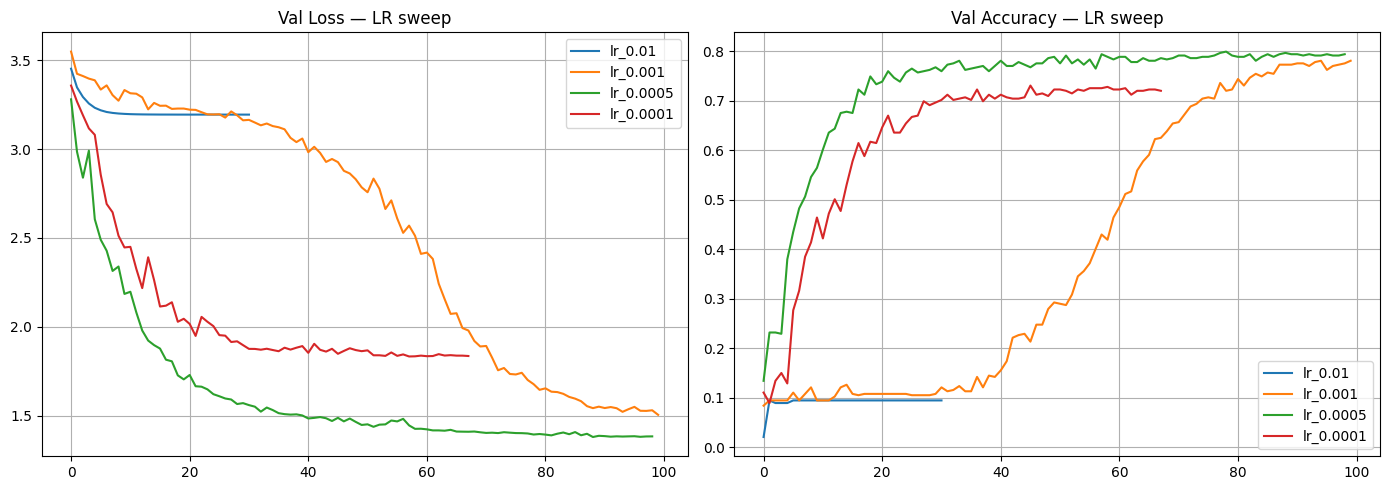

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776609541.060505  230356 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_290835__.104


45/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0462 - loss: 32.4723

I0000 00:00:1776609542.807501  230355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_290835__.104


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0473 - loss: 31.5358

I0000 00:00:1776609545.828224  230355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_292230__.30
I0000 00:00:1776609546.928556  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_292230__.30


48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.0640 - loss: 17.3119 - val_accuracy: 0.1398 - val_loss: 3.2494 - learning_rate: 5.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1530 - loss: 3.1957 - val_accuracy: 0.2032 - val_loss: 3.1026 - learning_rate: 5.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2038 - loss: 3.0408 - val_accuracy: 0.2691 - val_loss: 2.8819 - learning_rate: 5.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2322 - loss: 2.8803 - val_accuracy: 0.2955 - val_loss: 2.9371 - learning_rate: 5.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3127 - loss: 2.7382 - val_accuracy: 0.3483 - val_loss: 2.7586 - learning_rate: 5.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3701 - loss: 2.5608 - val_accuracy: 0.4697 - val_loss: 2.4400 - learning_rate: 5.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4558 - 

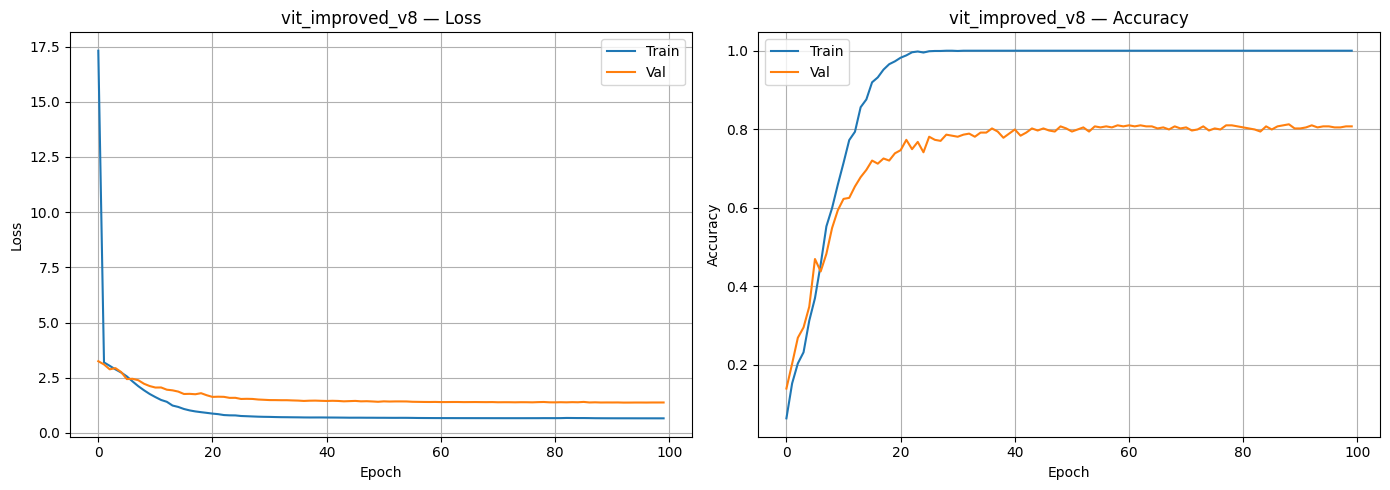

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}, wd={WEIGHT_DECAY}, dropout={DROPOUT_RATE}, ls={LABEL_SMOOTHING}, aug={AUGMENTATION}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4, v4: 26.1, v5: 18.3, v6: 18.7)")
print(f"  Note : loss avec label smoothing n'est pas comparable a v3/v4/v5 (min theorique different)")

I0000 00:00:1776609647.450637  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_292230__.30


vit_improved_v8 (best LR=0.0005, wd=0.0001, dropout=0.0, ls=0.1, aug=light):
  Train — Loss: 0.6638, Acc: 1.0000
  Val   — Loss: 1.3752, Acc: 0.8100
  Gap train/val: 19.0 pts  (v3: 20.4, v4: 26.1, v5: 18.3, v6: 18.7)
  Note : loss avec label smoothing n'est pas comparable a v3/v4/v5 (min theorique different)


I0000 00:00:1776609648.747065  230355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1009445__.21
I0000 00:00:1776609649.864517  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1009936__.21


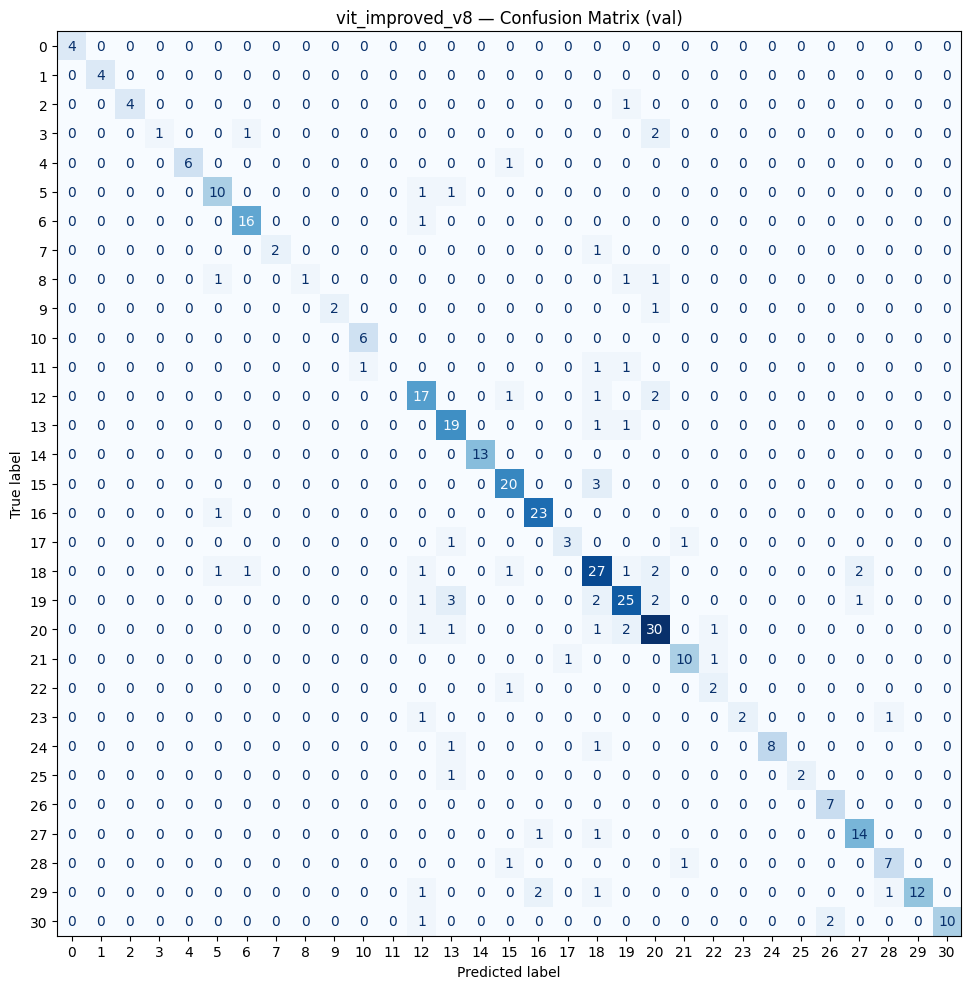

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

On garde le **fix retrain de v3** : `max(4*BEST_EPOCH, 60)` epochs avec **augmentation appliquee** au retrain aussi.

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)
all_ds = make_dataset(X_all, y_all_oh, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS      : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[
        callbacks.ReduceLROnPlateau(
            monitor='loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
        ),
        callbacks.TensorBoard(log_dir=final_log),
    ],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 89
RETRAIN_EPOCHS      : 356  (= max(89*4, 60))
Retraining on full dataset (1895 images) for 356 epochs
Epoch 1/356


I0000 00:00:1776609656.356307  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1020308__.104


56/60 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0638 - loss: 27.9531

I0000 00:00:1776609660.326952  230359 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1020308__.104
I0000 00:00:1776609660.635346  261187 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776609660.743983  261191 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776609660.989978  261187 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776609661.221390  261190 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_74', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776609661.323108  261189 subprocess_compilation.cc:348

60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 189ms/step - accuracy: 0.0776 - loss: 13.1061 - learning_rate: 5.0000e-04
Epoch 2/356
 6/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1177 - loss: 3.1462

I0000 00:00:1776609670.325581  230359 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_select_fusion_1', 56 bytes spill stores, 56 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_select_fusion', 56 bytes spill stores, 56 bytes spill loads



60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2042 - loss: 3.0452 - learning_rate: 5.0000e-04
Epoch 3/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2871 - loss: 2.8028 - learning_rate: 5.0000e-04
Epoch 4/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3641 - loss: 2.5947 - learning_rate: 5.0000e-04
Epoch 5/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4491 - loss: 2.3687 - learning_rate: 5.0000e-04
Epoch 6/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5240 - loss: 2.1315 - learning_rate: 5.0000e-04
Epoch 7/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6106 - loss: 1.9053 - learning_rate: 5.0000e-04
Epoch 8/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6522 - loss: 1.7621 - learning_rate: 5.0000e-04
Epoch 9/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7282 - loss: 1.5850 - learning_rate: 5.0000e-04
Epoch 10/356
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7794 - loss: 1.4135 - learning_rate: 5

I0000 00:00:1776609892.389296  230358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1296046__.30
I0000 00:00:1776609893.764319  230357 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1296046__.30



Final retrain train acc: 1.0000


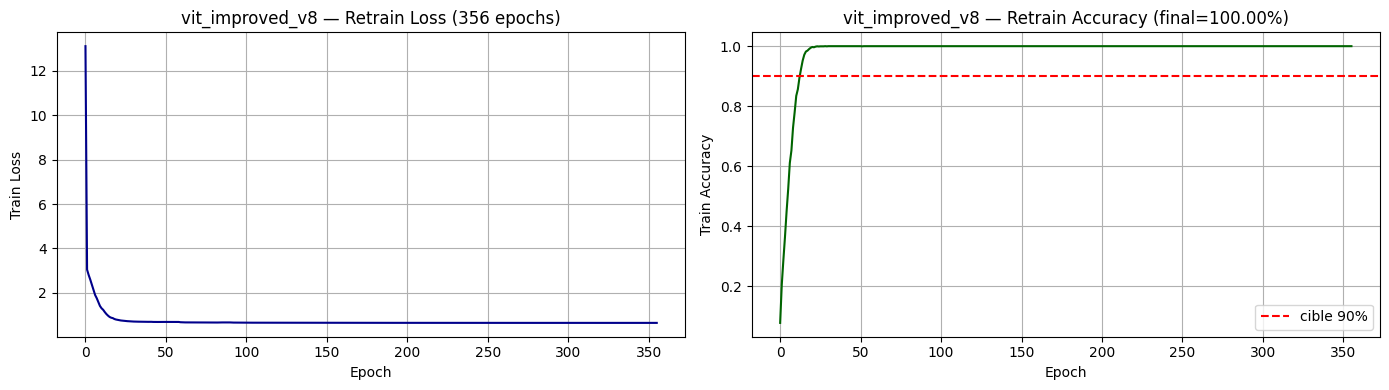

✅ Retrain converge : train acc = 100.00%


In [14]:
# Courbe de convergence du retrain — verifier que le modele a bien appris
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} — Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"⚠️  Retrain train acc = {final_train_acc:.2%} < 90%. Le dropout peut avoir regularise fortement -- c'est OK si la courbe monte regulierement. Verifier la courbe.")
else:
    print(f"✅ Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776609895.392462  230357 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1296792__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

I0000 00:00:1776609896.452015  230357 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1297259__.19
I0000 00:00:1776609896.675158  275035 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_86', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1776609896.714922  275039 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_86', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776609896.792372  275031 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_86', 52 bytes spill stores, 52 bytes spill loads

I0000 00:00:1776609896.875553  275025 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_86', 108 bytes spill stores, 108 bytes spill loads

I0000 00:00:1776609896.918407  275034 subprocess_com

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 367ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v8.csv


,row_id,similarity
0,0,0.690600
1,1,0.798384
2,2,0.475706
3,3,0.704890
4,4,0.635480


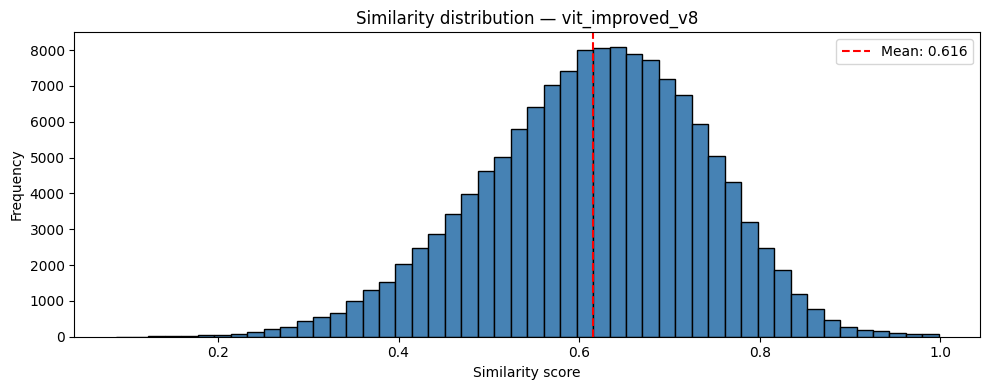

Similarity mean: 0.6156
Similarity std : 0.1226
Similarity min : 0.0866
Similarity max : 0.9984


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity min : {similarities.min():.4f}")
print(f"Similarity max : {similarities.max():.4f}")

## 6. Observations & Verdict

In [17]:
print(f"""
ViT Improved v8 (AdamW + wd={WEIGHT_DECAY} + Dropout=0.0 + LabelSmoothing={LABEL_SMOOTHING} + Aug=light):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Gap train/val: {(train_acc - val_acc)*100:.1f} pts
  (v6: 18.7, v7: 0.2 pts [underfitting])

  LR: {BEST_LR}, Weight decay: {WEIGHT_DECAY}, Dropout: 0.0 (retire), LabelSmoothing: {LABEL_SMOOTHING}
  Augmentation: light
  Activation: {ACTIVATION}, Embed dim: {EMBED_DIM}, Blocks: {NUM_BLOCKS}
  Best Epoch: {BEST_EPOCH} / Retrain Epochs: {RETRAIN_EPOCHS}
  Retrain train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}
  Embedding dim: {test_embeddings_norm.shape[1]}
  Similarity mean: {similarities.mean():.4f}  (v6: 0.46, v7: 0.54, ResNet v6: 0.62)
  Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]
""")



ViT Improved v8 (AdamW + wd=0.0001 + Dropout=0.0 + LabelSmoothing=0.1 + Aug=light):
  Train - Loss: 0.6638, Acc: 1.0000
  Val   - Loss: 1.3752, Acc: 0.8100
  Gap train/val: 19.0 pts
  (v6: 18.7, v7: 0.2 pts [underfitting])

  LR: 0.0005, Weight decay: 0.0001, Dropout: 0.0 (retire), LabelSmoothing: 0.1
  Augmentation: light
  Activation: relu, Embed dim: 64, Blocks: 3
  Best Epoch: 89 / Retrain Epochs: 356
  Retrain train acc: 1.0000
  Embedding dim: 260
  Similarity mean: 0.6156  (v6: 0.46, v7: 0.54, ResNet v6: 0.62)
  Similarity range: [0.0866, 0.9984]



### Results

| Metrique | v6 (+ LabelSmoothing) | v7 (+ Aug light) | v8 (+ Aug, - Dropout) |
|----------|-----------------------|------------------|------------------------|
| Architecture | ViT + relu | ViT + relu (idem) | ViT + relu (idem) |
| Regularisation | AdamW + Dropout(0.1) + LabelSmoothing | + Aug light | - Dropout + Aug light |
| BEST_LR | 5e-4 | 1e-4 | TODO |
| BEST_EPOCH (sweep) | 95 | 70 | TODO |
| Train accuracy (sweep) | 100.00 % | 9.70 % | TODO |
| Val accuracy (sweep) | 81.27 % | 9.50 % | TODO |
| Gap train/val | 18.7 pts | 0.2 pts (under) | TODO |
| Retrain train acc | 100.00 % | 96.36 % | TODO |
| Similarity mean | 0.4643 | 0.5360 | TODO |
| Kaggle public | **0.435** | 0.258 | TODO |
| Kaggle private | **0.421** | 0.273 | TODO |

### Analysis

- TODO : Les LRs hauts (5e-4, 1e-3) reconvergent-ils sans Dropout ? → valide/infirme l'hypothèse de sur-régularisation
- TODO : BEST_LR retrouve-t-il 5e-4 (comme v6) ?
- TODO : Gap train/val vs v7 (0.2 pts). Sans Dropout, le gap devrait remonter. A quel niveau ?
- TODO : Similarity mean : stable autour de 0.46 (v6) ou modifiée ?
- TODO : Kaggle vs v6 (0.435). L'augmentation seule (sans Dropout) fait-elle mieux ou moins bien que v6 ?

### Verdict

- [ ] Improvable -> Instructions for v9
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff cette technique, why ?

### Interpretation

_Free Space : points clés pour la soutenance._

- **Hypothèse testée** : Dropout et Aug sont-ils substituts ou complémentaires ?
- Si v8 > v7 (0.258) et BEST_LR > 1e-4 → **substituts confirmés** : l'accumulation était le problème.
- Si v8 ≈ v6 (0.435) → **l'augmentation est équivalente au Dropout** comme régulariseur.
- Si v8 < v6 → **le Dropout est plus utile que l'augmentation** pour ce ViT.
